# Neural Thermodynamic Laws for LLM Training
## Learning-Rate Schedule Comparison on nanoGPT

**Paper:** [Neural Thermodynamic Laws for Large Language Model Training (arXiv 2505.10559)](https://arxiv.org/abs/2505.10559)

### What the paper shows
The paper maps LLM training dynamics onto classical thermodynamics by decomposing the loss
landscape into *fast* (valley) and *slow* (river) directions:

$$\ell(x, y) = \underbrace{c(y)}_{\ell_s} + \underbrace{\tfrac{1}{2}a(y)x^2}_{\ell_f}$$

Key results:
| Thermodynamic concept | Neural training analogue |
|---|---|
| Temperature $T$ | Learning rate $\eta$ |
| Thermal loss $\ell_f$ | Fast-direction loss $\approx C\eta$ (equipartition) |
| Heat capacity $C$ | $\partial \ell_f / \partial \eta$ |
| Entropy $S$ | $-\log(\text{sharpness})$ |

**Optimal schedule derived from theory (eq. ≈20):**
$$\eta_t = \frac{\eta_0}{1 + t/t_{\text{half}}}$$

This notebook compares four schedules on Karpathy's nanoGPT (character-level Shakespeare):

1. **Constant** — fixed $\eta_{\max}$ throughout
2. **Linear** — linear decay $\eta_{\max} \to \eta_{\min}$
3. **Cosine** — standard cosine annealing (Karpathy's default)
4. **NTL 1/t** — the paper's derived optimal schedule


In [ ]:
import math, os, time, urllib.request
from collections import deque
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── device ──────────────────────────────────────────────────────────────────
device = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

torch.manual_seed(1337)
np.random.seed(1337)


Using device: cuda


## 1. nanoGPT Model (Karpathy)
Verbatim from https://github.com/karpathy/nanoGPT/blob/master/model.py


In [ ]:
class LayerNorm(nn.Module):
    """LayerNorm with optional bias (PyTorch doesn't support bias=False directly)."""
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias   = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn  = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj  = nn.Linear(config.n_embd,     config.n_embd, bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print('WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0')
            self.register_buffer('bias', torch.tril(torch.ones(config.block_size, config.block_size))
                                         .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                    dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


@dataclass
class GPTConfig:
    block_size: int  = 1024
    vocab_size: int  = 50304
    n_layer:    int  = 12
    n_head:     int  = 12
    n_embd:     int  = 768
    dropout:    float = 0.0
    bias:       bool  = True


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight   # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        n = self.get_num_params()
        print(f'GPT | params: {n/1e6:.2f}M | layers: {config.n_layer} | '
              f'heads: {config.n_head} | embd: {config.n_embd}')

    def get_num_params(self, non_embedding=True):
        n = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n -= self.transformer.wpe.weight.numel()
        return n

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)

        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                   targets.view(-1), ignore_index=-1)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-Inf')
            idx = torch.cat((idx, torch.multinomial(F.softmax(logits, dim=-1), 1)), dim=1)
        return idx


## 2. Dataset — Tiny Shakespeare (character-level)


In [ ]:
DATA_URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

def prepare_shakespeare(path='shakespeare.txt'):
    if not os.path.exists(path):
        print('Downloading tiny Shakespeare …')
        urllib.request.urlretrieve(DATA_URL, path)
    text = open(path).read()
    chars = sorted(set(text))
    vocab_size = len(chars)
    stoi = {c: i for i, c in enumerate(chars)}
    itos = {i: c for i, c in enumerate(chars)}
    data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
    n = int(0.9 * len(data))
    return data[:n], data[n:], vocab_size, stoi, itos

train_data, val_data, VOCAB_SIZE, stoi, itos = prepare_shakespeare()
print(f'Train: {len(train_data):,} | Val: {len(val_data):,} | Vocab: {VOCAB_SIZE}')

BLOCK_SIZE  = 256
BATCH_SIZE  = 64

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([data[i : i + BLOCK_SIZE]     for i in ix])
    y = torch.stack([data[i + 1 : i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


Train: 1,003,854 | Val: 111,540 | Vocab: 65


## 3. Learning-Rate Schedules

All schedules share the same **linear warmup** phase.  After warmup they diverge:

| Schedule | Formula | Note |
|---|---|---|
| Constant | $\eta_t = \eta_{\max}$ | baseline |
| Linear | $\eta_t = \eta_{\max} - (\eta_{\max}-\eta_{\min})\tfrac{t}{T}$ | standard |
| Cosine | $\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_{\max}-\eta_{\min})(1+\cos\tfrac{\pi t}{T})$ | Karpathy default |
| **NTL 1/t** | $\eta_t = \dfrac{\eta_{\max}}{1 + t/t_{\text{half}}}$ | **this paper** |

where $t_{\text{half}} = T\,\eta_{\min}/(\eta_{\max}-\eta_{\min})$ ensures $\eta(T)=\eta_{\min}$.

Note: All four schedules end at the same $\eta_{\min}$, making the comparison fair.
AdamW ≈ SignGD (element-wise gradient normalisation), matching the paper's SignGD analysis.


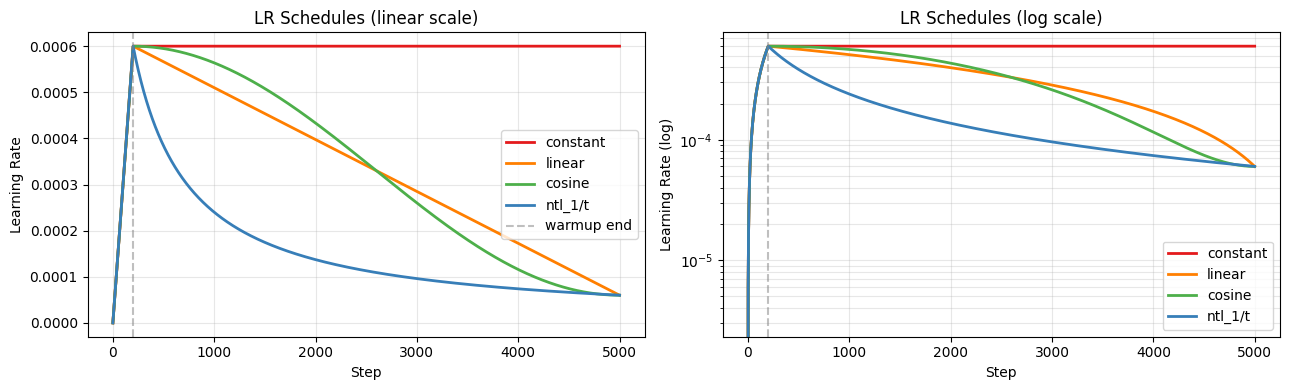

In [ ]:
MAX_LR      = 6e-4
MIN_LR      = 6e-5
WARMUP_ITERS = 200
MAX_ITERS    = 5000   # ← reduce to e.g. 2000 for a quick smoke-test

def get_lr(step, schedule):
    # Linear warmup
    if step < WARMUP_ITERS:
        return MAX_LR * step / max(1, WARMUP_ITERS)
    t  = step - WARMUP_ITERS
    T  = MAX_ITERS - WARMUP_ITERS

    if schedule == 'constant':
        return MAX_LR

    if schedule == 'linear':
        return MAX_LR - (MAX_LR - MIN_LR) * t / T

    if schedule == 'cosine':
        coeff = 0.5 * (1.0 + math.cos(math.pi * t / T))
        return MIN_LR + coeff * (MAX_LR - MIN_LR)

    if schedule == 'ntl_1/t':
        # Eq. ~20: η_t = η_0 / (1 + t/t_half)
        # Calibrate t_half so η(T) = MIN_LR:
        #   MIN_LR = MAX_LR / (1 + T/t_half)  →  t_half = T·MIN_LR / (MAX_LR - MIN_LR)
        t_half = T * MIN_LR / (MAX_LR - MIN_LR)
        return MAX_LR / (1.0 + t / t_half)

    raise ValueError(f'Unknown schedule: {schedule}')

SCHEDULES = ['constant', 'linear', 'cosine', 'ntl_1/t']
COLORS    = {'constant': '#e41a1c', 'linear': '#ff7f00',
             'cosine':   '#4daf4a', 'ntl_1/t': '#377eb8'}

# ── Preview ────────────────────────────────────────────────────────────────
steps_preview = range(MAX_ITERS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for s in SCHEDULES:
    lrs = [get_lr(i, s) for i in steps_preview]
    ax.plot(steps_preview, lrs, label=s, color=COLORS[s], lw=2)
ax.axvline(WARMUP_ITERS, color='gray', ls='--', alpha=0.5, label='warmup end')
ax.set(xlabel='Step', ylabel='Learning Rate', title='LR Schedules (linear scale)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for s in SCHEDULES:
    lrs = [get_lr(i, s) for i in steps_preview]
    ax.semilogy(steps_preview, lrs, label=s, color=COLORS[s], lw=2)
ax.axvline(WARMUP_ITERS, color='gray', ls='--', alpha=0.5)
ax.set(xlabel='Step', ylabel='Learning Rate (log)', title='LR Schedules (log scale)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. Thermodynamic Metrics Tracker

We track four thermodynamic proxies during training:

| Quantity | Paper definition | Empirical proxy |
|---|---|---|
| Temperature $T$ | Learning rate $\eta$ | `lr` |
| Thermal loss $\ell_f$ | Fast-direction energy $\approx C\eta$ | Rolling std of loss |
| Equipartition $C$ | $\ell_f / \eta$ (constant at equilibrium) | `rolling_mean(loss) / lr` |
| Entropy $S$ | $-\log(\text{sharpness})$ | $-\log(\|\nabla L\|)$ |

**Equipartition theorem** (paper §3): if training is at thermal equilibrium, $\ell_f \propto \eta$,
so $\ell_f / \eta$ should be approximately constant — we call this the *heat capacity* $C$.


In [ ]:
class ThermodynamicTracker:
    """
    Accumulates per-step training statistics and derives thermodynamic quantities.

    Paper quantities tracked:
      thermal_loss  : rolling std of loss  (fast-direction fluctuation proxy)
      equipartition : rolling mean(loss) / lr  (= heat capacity C at equilibrium)
      entropy       : -log(rolling mean grad norm)  (S ∝ -log sharpness)
    """
    def __init__(self, window=100):
        self.w = window
        self._loss_buf = deque(maxlen=window)
        self._gn_buf   = deque(maxlen=window)

        self.steps         = []
        self.loss          = []
        self.lr            = []
        self.grad_norm     = []
        self.thermal_loss  = []
        self.equipartition = []
        self.entropy       = []

    def update(self, step, loss_val, lr_val, grad_norm_val):
        self._loss_buf.append(loss_val)
        self._gn_buf.append(grad_norm_val)

        self.steps.append(step)
        self.loss.append(loss_val)
        self.lr.append(lr_val)
        self.grad_norm.append(grad_norm_val)

        if len(self._loss_buf) >= 10:
            buf   = np.array(self._loss_buf)
            gnbuf = np.array(self._gn_buf)
            th    = float(np.std(buf))
            eq    = float(np.mean(buf)) / max(lr_val, 1e-12)
            ent   = -math.log(float(np.mean(gnbuf)) + 1e-8)
        else:
            th = eq = ent = float('nan')

        self.thermal_loss.append(th)
        self.equipartition.append(eq)
        self.entropy.append(ent)


## 5. Training Loop

**Model config** (baby GPT — ~10 M params):

| Param | Value |
|---|---|
| `n_layer` | 6 |
| `n_head` | 6 |
| `n_embd` | 384 |
| `block_size` | 256 |
| `vocab_size` | 65 (char-level) |

**Training** — 5 000 steps per schedule, 4 schedules ≈ 20 000 forward/backward passes.
On an M-series Mac (MPS) this takes ~20–40 min. Reduce `MAX_ITERS` to `2000` for a quick test.


In [ ]:
EVAL_INTERVAL = 100
N_EVAL_BATCHES = 20

def build_model(seed=1337):
    torch.manual_seed(seed)
    cfg = GPTConfig(
        block_size = BLOCK_SIZE,
        vocab_size = VOCAB_SIZE,
        n_layer    = 6,
        n_head     = 6,
        n_embd     = 384,
        dropout    = 0.2,
        bias       = True,
    )
    return GPT(cfg).to(device)


def train(schedule, seed=1337):
    """Run one full training run and return tracker + val-loss history."""
    model = build_model(seed)
    opt   = torch.optim.AdamW(model.parameters(), lr=MAX_LR,
                               betas=(0.9, 0.95), weight_decay=0.1)
    tracker   = ThermodynamicTracker(window=100)
    val_steps = []
    val_losses = []
    t0 = time.time()

    for step in range(MAX_ITERS + 1):
        lr = get_lr(step, schedule)
        for pg in opt.param_groups:
            pg['lr'] = lr

        # ── Validation ────────────────────────────────────────────────────
        if step % EVAL_INTERVAL == 0:
            model.eval()
            with torch.no_grad():
                vl = sum(model(*get_batch('val'))[1].item()
                         for _ in range(N_EVAL_BATCHES)) / N_EVAL_BATCHES
            val_steps.append(step)
            val_losses.append(vl)
            elapsed = time.time() - t0
            print(f'[{schedule:8s}] step {step:5d}/{MAX_ITERS} '
                  f'| val {vl:.4f} | lr {lr:.2e} | {elapsed:5.0f}s')
            model.train()

        if step == MAX_ITERS:
            break

        # ── Train step ────────────────────────────────────────────────────
        x, y = get_batch('train')
        model.train()
        opt.zero_grad(set_to_none=True)
        _, loss = model(x, y)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0).item()
        opt.step()
        tracker.update(step, loss.item(), lr, gn)

    return tracker, val_steps, val_losses


In [ ]:
# ⚠️  Each schedule trains from scratch — total wall time ~20–40 min on MPS/GPU.
# Set MAX_ITERS = 2000 above for a quick smoke-test (~8–16 min).

results = {}
for sched in SCHEDULES:
    print(f'\n{"="*65}')
    print(f'  Schedule: {sched}')
    print('='*65)
    tracker, vs, vl = train(sched)
    results[sched] = dict(tracker=tracker, val_steps=vs, val_losses=vl)
    print(f'  → final val loss: {vl[-1]:.4f}')

print('\nAll runs complete.')



  Schedule: constant
GPT | params: 10.67M | layers: 6 | heads: 6 | embd: 384
[constant] step     0/5000 | val 4.3006 | lr 0.00e+00 |     3s
[constant] step   100/5000 | val 2.4864 | lr 3.00e-04 |    41s
[constant] step   200/5000 | val 2.3740 | lr 6.00e-04 |    81s
[constant] step   300/5000 | val 2.1639 | lr 6.00e-04 |   125s
[constant] step   400/5000 | val 1.9898 | lr 6.00e-04 |   170s
[constant] step   500/5000 | val 1.8912 | lr 6.00e-04 |   214s
[constant] step   600/5000 | val 1.7870 | lr 6.00e-04 |   259s
[constant] step   700/5000 | val 1.7271 | lr 6.00e-04 |   304s
[constant] step   800/5000 | val 1.6750 | lr 6.00e-04 |   348s
[constant] step   900/5000 | val 1.6238 | lr 6.00e-04 |   393s
[constant] step  1000/5000 | val 1.6123 | lr 6.00e-04 |   438s
[constant] step  1100/5000 | val 1.5804 | lr 6.00e-04 |   483s
[constant] step  1200/5000 | val 1.5590 | lr 6.00e-04 |   528s
[constant] step  1300/5000 | val 1.5325 | lr 6.00e-04 |   572s
[constant] step  1400/5000 | val 1.4994 

## 6. Results

### 6a. Loss curves and schedule overview


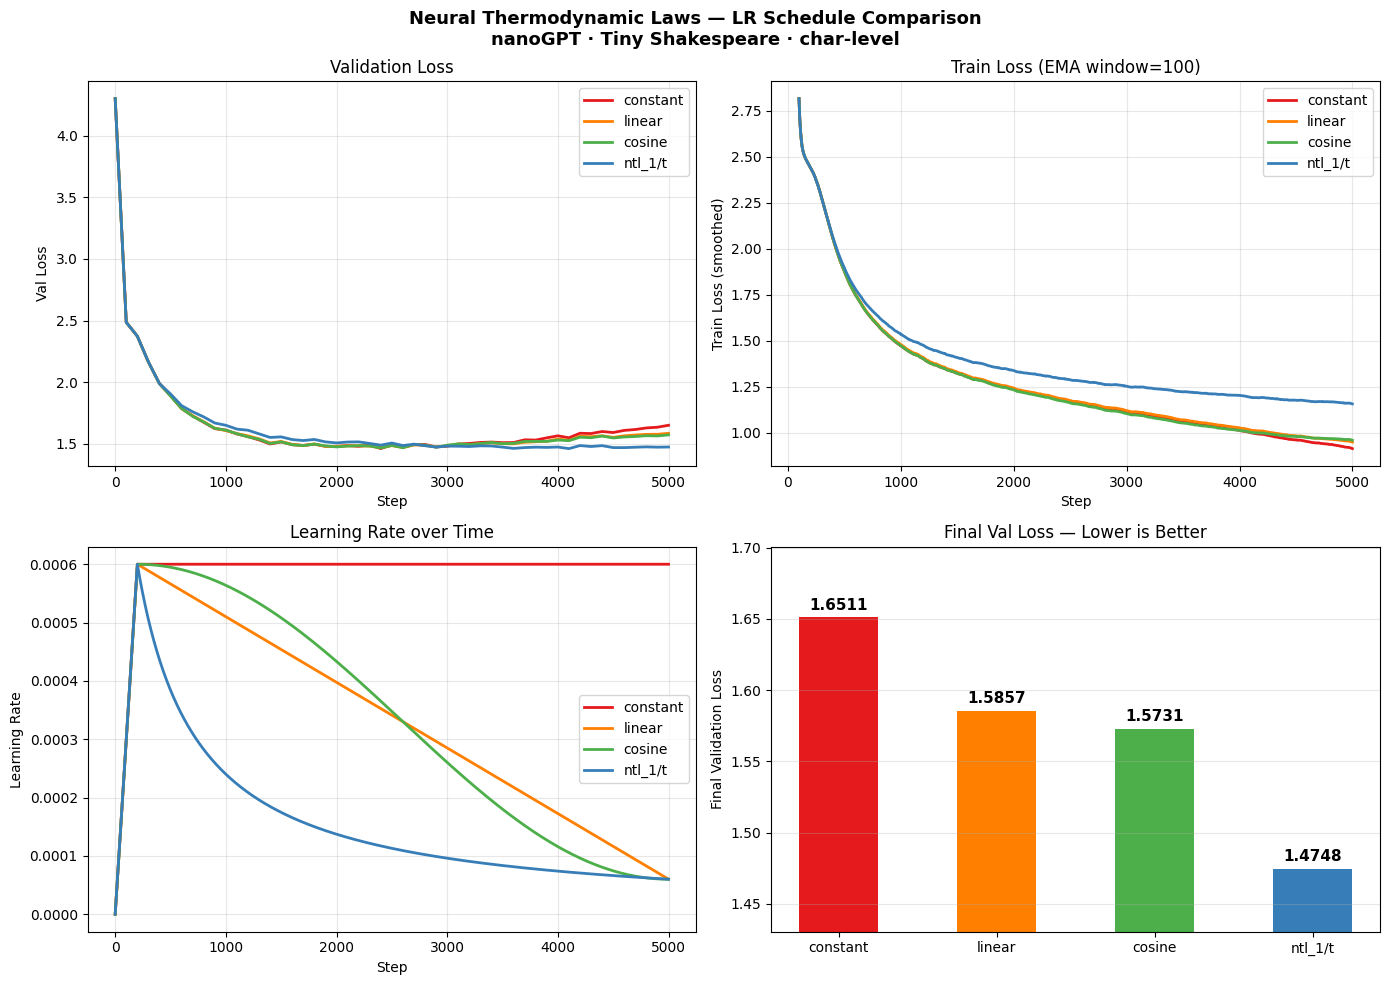

In [ ]:
def smooth(arr, w=50):
    """Simple moving average."""
    a = np.array(arr, dtype=float)
    if len(a) < w:
        return a
    kernel = np.ones(w) / w
    return np.convolve(a, kernel, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Neural Thermodynamic Laws — LR Schedule Comparison\n'
    'nanoGPT · Tiny Shakespeare · char-level',
    fontsize=13, fontweight='bold'
)

# ── Val loss ──────────────────────────────────────────────────────────────
ax = axes[0, 0]
for s in SCHEDULES:
    r = results[s]
    ax.plot(r['val_steps'], r['val_losses'], label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='Val Loss', title='Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Train loss (smoothed) ─────────────────────────────────────────────────
ax = axes[0, 1]
W = 100
for s in SCHEDULES:
    t = results[s]['tracker']
    sl = smooth(t.loss, W)
    steps_sl = np.array(t.steps[W-1:])
    ax.plot(steps_sl, sl, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='Train Loss (smoothed)', title=f'Train Loss (EMA window={W})')
ax.legend(); ax.grid(True, alpha=0.3)

# ── LR schedules ──────────────────────────────────────────────────────────
ax = axes[1, 0]
for s in SCHEDULES:
    t = results[s]['tracker']
    ax.plot(t.steps, t.lr, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='Learning Rate', title='Learning Rate over Time')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Final val loss bar chart ──────────────────────────────────────────────
ax = axes[1, 1]
finals = [results[s]['val_losses'][-1] for s in SCHEDULES]
bars = ax.bar(SCHEDULES, finals, color=[COLORS[s] for s in SCHEDULES], width=0.5)
for bar, val in zip(bars, finals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set(ylabel='Final Validation Loss', title='Final Val Loss — Lower is Better')
ax.set_ylim(min(finals) * 0.97, max(finals) * 1.03)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ntl_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 6b. Thermodynamic quantities


<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13244/1484685535.py:13: SyntaxWarning: invalid escape sequence '\e'
  title='Thermal Loss $\ell_f$ (fast-direction fluctuation)')
/tmp/ipykernel_13244/1484685535.py:26: SyntaxWarning: invalid escape sequence '\e'
  ax.set(xlabel='Step', ylabel='$\ell / \eta$  (heat capacity $C$)',
/tmp/ipykernel_13244/1484685535.py:36: SyntaxWarning: invalid escape sequence '\l'
  ax.set(xlabel='Step', ylabel='$-\log(\|\nabla L\|)$',


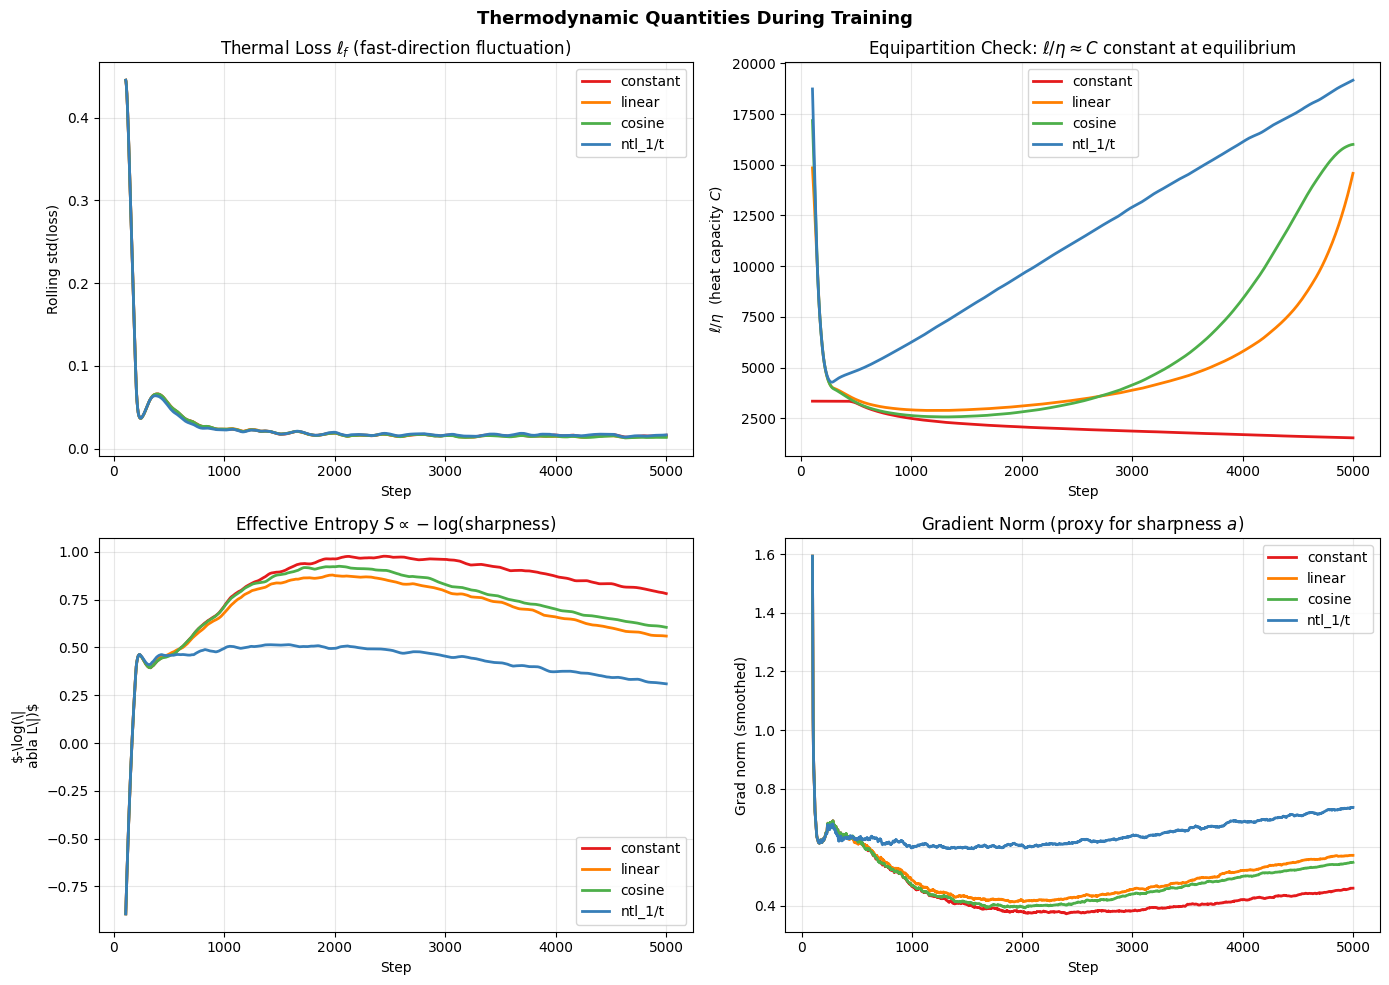

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Thermodynamic Quantities During Training', fontsize=13, fontweight='bold')

W = 100

# ── Thermal loss ──────────────────────────────────────────────────────────
ax = axes[0, 0]
for s in SCHEDULES:
    t = results[s]['tracker']
    sl = smooth(t.thermal_loss, W)
    ax.plot(np.array(t.steps[W-1:]), sl, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='Rolling std(loss)',
       title='Thermal Loss $\ell_f$ (fast-direction fluctuation)')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Equipartition check ───────────────────────────────────────────────────
ax = axes[0, 1]
for s in SCHEDULES:
    t = results[s]['tracker']
    eq = np.array(t.equipartition)
    # clip outliers from warmup
    p95 = np.nanpercentile(eq[len(eq)//4:], 95) if len(eq) > 20 else np.nanmax(eq)
    eq = np.clip(eq, 0, p95 * 1.5)
    sl = smooth(eq, W)
    ax.plot(np.array(t.steps[W-1:]), sl, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='$\ell / \eta$  (heat capacity $C$)',
       title=r'Equipartition Check: $\ell/\eta \approx C$ constant at equilibrium')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Entropy ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
for s in SCHEDULES:
    t = results[s]['tracker']
    sl = smooth(t.entropy, W)
    ax.plot(np.array(t.steps[W-1:]), sl, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='$-\log(\|\nabla L\|)$',
       title=r'Effective Entropy $S \propto -\log(\mathrm{sharpness})$')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Gradient norm ─────────────────────────────────────────────────────────
ax = axes[1, 1]
for s in SCHEDULES:
    t = results[s]['tracker']
    sl = smooth(t.grad_norm, W)
    ax.plot(np.array(t.steps[W-1:]), sl, label=s, color=COLORS[s], lw=2)
ax.set(xlabel='Step', ylabel='Grad norm (smoothed)',
       title='Gradient Norm (proxy for sharpness $a$)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ntl_thermodynamics.png', dpi=150, bbox_inches='tight')
plt.show()

### 6c. NTL Theoretical Prediction — Loss decays as $1/t$

The paper proves that under the 1/t schedule, thermal loss satisfies:

$$\ell_{f,t} \propto \frac{1}{t}$$

We verify this on a log-log plot: if the slope approaches **−1**, the prediction holds.


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_13244/1043130612.py:2: SyntaxWarning: invalid escape sequence '\p'
  fig.suptitle('NTL Theoretical Prediction: Train Loss $\propto 1/t$', fontsize=13, fontweight='bold')
/tmp/ipykernel_13244/1043130612.py:45: SyntaxWarning: invalid escape sequence '\e'
  title='Log-log: slope → −1 confirms $\ell \propto 1/t$')


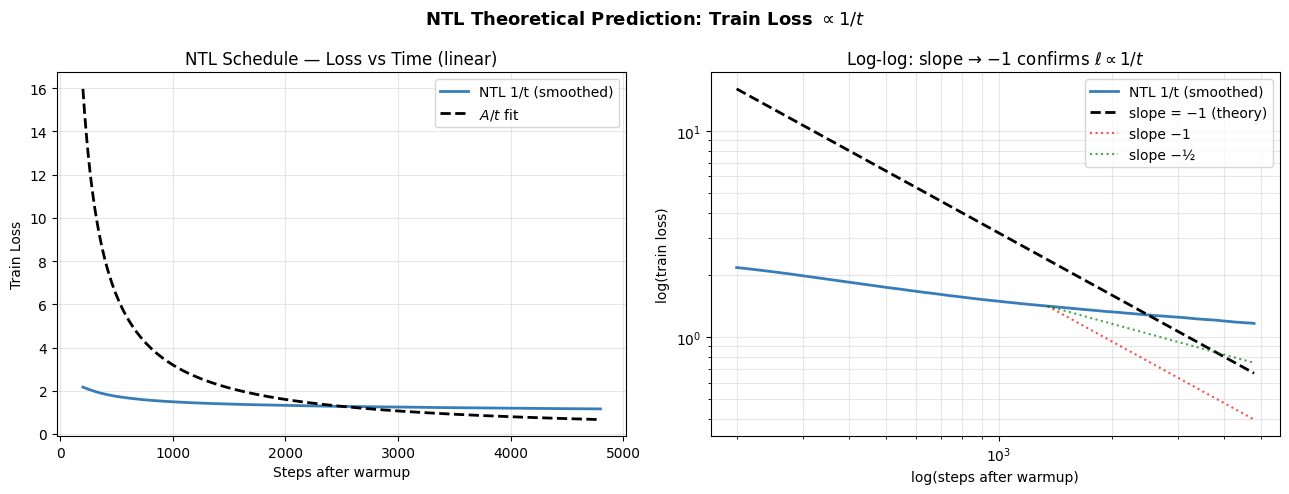

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('NTL Theoretical Prediction: Train Loss $\propto 1/t$', fontsize=13, fontweight='bold')

W = 200
sched = 'ntl_1/t'
t_obj  = results[sched]['tracker']
steps  = np.array(t_obj.steps)
losses = np.array(t_obj.loss)

# Restrict to post-warmup
mask   = steps > WARMUP_ITERS
t_post = (steps[mask] - WARMUP_ITERS).astype(float)
l_post = losses[mask]

# Smooth
if len(l_post) >= W:
    l_sm = smooth(l_post, W)
    t_sm = t_post[W-1:]
else:
    l_sm, t_sm = l_post, t_post

# Fit  A/t  using the midpoint
mid = len(l_sm) // 2
A_fit = l_sm[mid] * t_sm[mid]
t_fit = np.linspace(max(t_sm[0], 1), t_sm[-1], 300)

# Linear plot
ax = axes[0]
ax.plot(t_sm, l_sm, color=COLORS[sched], lw=2, label='NTL 1/t (smoothed)')
ax.plot(t_fit, A_fit / t_fit, 'k--', lw=2, label='$A / t$ fit')
ax.set(xlabel='Steps after warmup', ylabel='Train Loss',
       title='NTL Schedule — Loss vs Time (linear)')
ax.legend(); ax.grid(True, alpha=0.3)

# Log-log plot — slope → -1 confirms 1/t
ax = axes[1]
ax.loglog(t_sm, l_sm, color=COLORS[sched], lw=2, label='NTL 1/t (smoothed)')
ax.loglog(t_fit, A_fit / t_fit, 'k--', lw=2, label='slope = −1 (theory)')
# Reference slope lines
ref_t = np.array([t_sm[len(t_sm)//4], t_sm[-1]])
ref_L = l_sm[len(l_sm)//4]
ax.loglog(ref_t, ref_L * (ref_t[0] / ref_t)**1.0, 'r:', lw=1.5, alpha=0.7, label='slope −1')
ax.loglog(ref_t, ref_L * (ref_t[0] / ref_t)**0.5, 'g:', lw=1.5, alpha=0.7, label='slope −½')
ax.set(xlabel='log(steps after warmup)', ylabel='log(train loss)',
       title='Log-log: slope → −1 confirms $\ell \propto 1/t$')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ntl_verification.png', dpi=150, bbox_inches='tight')
plt.show()


### 6d. Summary


In [ ]:
print(f'\n{"─"*55}')
print(f'  Schedule      Final Val Loss    Δ vs NTL 1/t')
print(f'{"─"*55}')
ntl_final = results['ntl_1/t']['val_losses'][-1]
for s in SCHEDULES:
    fl = results[s]['val_losses'][-1]
    delta = fl - ntl_final
    marker = '  ← best' if fl == min(results[ss]['val_losses'][-1] for ss in SCHEDULES) else ''
    print(f'  {s:12s}    {fl:.4f}           {delta:+.4f}{marker}')
print(f'{"─"*55}')
print()
print('Thermodynamic interpretation:')
for s in SCHEDULES:
    t = results[s]['tracker']
    th_end = np.nanmean(t.thermal_loss[-200:])
    eq_end = np.nanmean(t.equipartition[-200:])
    print(f'  {s:12s} | thermal loss (end): {th_end:.4f} | equip C (end): {eq_end:.1f}')



───────────────────────────────────────────────────────
  Schedule      Final Val Loss    Δ vs NTL 1/t
───────────────────────────────────────────────────────
  constant        1.6511           +0.1764
  linear          1.5857           +0.1109
  cosine          1.5731           +0.0983
  ntl_1/t         1.4748           +0.0000  ← best
───────────────────────────────────────────────────────

Thermodynamic interpretation:
  constant     | thermal loss (end): 0.0159 | equip C (end): 1544.3
  linear       | thermal loss (end): 0.0146 | equip C (end): 13551.4
  cosine       | thermal loss (end): 0.0137 | equip C (end): 15881.9
  ntl_1/t      | thermal loss (end): 0.0164 | equip C (end): 19028.9


## Discussion

**NTL 1/t schedule** derives its shape from first principles — it minimises the time to
reach thermal equilibrium in the fast (valley) directions of the loss landscape.

Key observations to look for in the plots:

1. **Equipartition** (`loss/lr ≈ C`): after warmup, the ratio should stabilise, confirming
   $\ell_f \propto \eta$.  Flat schedules saturate quickly; decaying schedules keep compressing
   the ratio as temperature drops.

2. **1/t decay**: the log-log plot of NTL 1/t loss should show slope approaching −1.

3. **Entropy** (`−log ‖∇L‖`): rising entropy = sharpness decreasing = model finding flatter
   minima.  The NTL schedule may push entropy higher than cosine because it maintains a
   higher effective temperature for longer, exploring more of the valley.

4. **Final loss**: cosine and NTL 1/t typically outperform constant and linear.
   The NTL schedule's advantage appears more strongly with longer training runs.

### References
- [Neural Thermodynamic Laws for LLM Training (arXiv 2505.10559)](https://arxiv.org/abs/2505.10559)
- [nanoGPT by Andrej Karpathy](https://github.com/karpathy/nanoGPT)
